In [18]:
"""
Logistic Regression (GLM - Binomial) Analysis
==============================================
Research Question:
    To what extent do subjective confidence, frame type (Before Boundary BB vs.
    Event-Middle EM), and video editing style (NB vs. AB) predict the probability
    of correct frame recognition?

Model:
    DV  : resp.corr        (binary: 1 = correct, 0 = incorrect)
    IVs : Condition        (NB vs. AB)
          Target_Type      (BB vs. EM, extracted from target_img filename)
          Confidence       (conf_radio.response, 1-5 Likert scale)
    Interaction: Condition × Confidence  (tests boundary-advantage / confidence link)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# statsmodels for GLM
import statsmodels.formula.api as smf
import statsmodels.api as sm

# scipy for odds-ratio CIs from log-OR
from scipy import stats

# ── Paths ─────────────────────────────────────────────────────────────────────
CLEANED_DIR = Path("../data/individuals_cleaned")
OUTPUT_DIR  = Path("../exploration_output/logistic_regression")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [19]:
# ── Helpers ───────────────────────────────────────────────────────────────────
def parse_list_value(val):
    """Parse values stored as string lists like '[9.14]'."""
    if pd.isna(val):
        return np.nan
    if isinstance(val, (int, float)):
        return float(val)
    try:
        val_str = str(val).strip()
        if val_str.startswith('[') and val_str.endswith(']'):
            inner = val_str[1:-1].strip()
            if inner:
                return float(inner)
        return float(val_str)
    except Exception:
        return np.nan


def extract_target_type(img_path: str) -> str:
    """
    Extract target type from filename.
    Filenames look like: frames\\Vid33_BB_T.png  or  frames/Vid9_EM_T.png
    Returns 'BB' or 'EM', else NaN.
    """
    if pd.isna(img_path):
        return np.nan
    img_path = str(img_path).replace("\\", "/")
    fname = img_path.split("/")[-1]        # e.g. "Vid33_BB_T.png"
    parts = fname.split("_")               # ['Vid33', 'BB', 'T.png']
    for part in parts:
        if part in ("BB", "EM"):
            return part
    return np.nan


# ── Data Loading ──────────────────────────────────────────────────────────────
def build_trial_dataframe() -> pd.DataFrame:
    """
    Walk every cleaned participant CSV, extract trial-level rows, and
    return one combined long-format DataFrame ready for modelling.
    """
    csv_files = sorted(CLEANED_DIR.glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {CLEANED_DIR}")

    print(f"Loading {len(csv_files)} participant files …")
    records = []

    for csv_file in csv_files:
        try:
            df = pd.read_csv(csv_file, low_memory=False)

            # ── participant meta ──────────────────────────────────────────────
            condition     = ('AB' if '_AB_' in csv_file.name else
                             'NB' if '_NB_' in csv_file.name else 'Unknown')
            participant_id = csv_file.stem.split('_')[0]   # e.g. 'sub14'

            # ── keep only recognition-task trial rows ─────────────────────────
            trials = df[df['resp.corr'].notna()].copy()
            if trials.empty:
                continue

            # ── parse columns ─────────────────────────────────────────────────
            trials['resp.corr']         = pd.to_numeric(trials['resp.corr'],         errors='coerce')
            trials['conf_radio.response'] = trials['conf_radio.response'].apply(parse_list_value)
            trials['resp.rt']           = trials['resp.rt'].apply(parse_list_value)

            # ── derive Target_Type ────────────────────────────────────────────
            trials['Target_Type'] = trials['target_img'].apply(extract_target_type)

            # ── assemble record per trial ─────────────────────────────────────
            for _, row in trials.iterrows():
                records.append({
                    'Participant'  : participant_id,
                    'Condition'    : condition,
                    'Target_Type'  : row['Target_Type'],
                    'Confidence'   : row['conf_radio.response'],
                    'Resp_Corr'    : row['resp.corr'],
                    'RT'           : row['resp.rt'],
                    'movie_id'     : row.get('movie_id', np.nan),
                    'target_img'   : row.get('target_img', np.nan),
                })

        except Exception as e:
            print(f"  ⚠  Error reading {csv_file.name}: {e}")

    long_df = pd.DataFrame(records)
    return long_df


# ── Pre-processing ────────────────────────────────────────────────────────────
def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    """
    Clean and encode the long-format trial DataFrame.
    """
    print(f"\nTotal trials before cleaning : {len(df)}")

    # Drop rows missing key variables
    df = df.dropna(subset=['Resp_Corr', 'Confidence', 'Target_Type', 'Condition'])
    print(f"Total trials after dropna    : {len(df)}")

    # Ensure types
    df['Resp_Corr']  = df['Resp_Corr'].astype(int)
    df['Confidence'] = df['Confidence'].astype(float)

    # ── Dummy / treatment coding ──────────────────────────────────────────────
    # Reference levels: NB for Condition, BB for Target_Type
    df['Condition_AB']   = (df['Condition']   == 'AB').astype(int)   # 1 = AB, 0 = NB
    df['TargetType_EM']  = (df['Target_Type'] == 'EM').astype(int)   # 1 = EM, 0 = BB

    # Centre Confidence for interpretability of main effects (grand-mean centred)
    df['Confidence_c'] = df['Confidence'] - df['Confidence'].mean()

    print(f"\nCondition breakdown:")
    print(df['Condition'].value_counts())
    print(f"\nTarget_Type breakdown:")
    print(df['Target_Type'].value_counts())
    print(f"\nConfidence distribution:")
    print(df['Confidence'].describe())
    print(f"\nOverall accuracy: {df['Resp_Corr'].mean()*100:.2f}%")

    return df


def plot_correlation_heatmap(df):
    """
    Plots a correlation heatmap with values annotated in each cell.
    Only numeric columns are used.
    """
    # Select numeric columns
    numeric_df = df.select_dtypes(include=['int64', 'float64'])

    # Compute correlation matrix
    corr = numeric_df.corr()

    # Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        corr,
        annot=True,           # show numbers
        fmt=".2f",            # 2 decimal places
        cmap="coolwarm",
        square=True,
        cbar=True,
        linewidths=0.5
    )

    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()

# ── Logistic Regression ───────────────────────────────────────────────────────
def run_logistic_regression(df: pd.DataFrame):
    """
    Fit GLM Binomial logistic regression using statsmodels.
    Formula includes main effects + Condition × Confidence interaction.
    """
    print("\n" + "="*70)
    print("LOGISTIC REGRESSION (GLM - Binomial)")
    print("="*70)

    # Formula (statsmodels patsy-style)
    # Condition_AB coded 0/1, TargetType_EM coded 0/1, Confidence_c grand-mean centred
    formula = "Resp_Corr ~ Condition_AB + TargetType_EM + Confidence_c + Condition_AB:Confidence_c"

    model = smf.glm(
        formula = formula,
        data    = df,
        family  = sm.families.Binomial()
    )
    result = model.fit()

    print(result.summary())

    return result

In [20]:
# 1. Build trial-level dataframe from all cleaned CSVs
df_raw = build_trial_dataframe()

print(df_raw.isna().sum())

# 2. Preprocess & encode
df = preprocess(df_raw)



Loading 166 participant files …
Participant    0
Condition      0
Target_Type    0
Confidence     0
Resp_Corr      0
RT             0
movie_id       0
target_img     0
dtype: int64

Total trials before cleaning : 6640
Total trials after dropna    : 6640

Condition breakdown:
Condition
NB    3480
AB    3160
Name: count, dtype: int64

Target_Type breakdown:
Target_Type
BB    3320
EM    3320
Name: count, dtype: int64

Confidence distribution:
count    6640.000000
mean        4.138404
std         1.140116
min         1.000000
25%         3.000000
50%         5.000000
75%         5.000000
max         5.000000
Name: Confidence, dtype: float64

Overall accuracy: 85.48%


In [21]:
df.head()

,Participant,Condition,Target_Type,Confidence,Resp_Corr,RT,movie_id,target_img,Condition_AB,TargetType_EM,Confidence_c
0,Sub41,AB,BB,2.0,0,14.088629,21.0,frames\Vid21_BB_T.png,1,0,-2.138404
1,Sub41,AB,BB,2.0,1,20.329053,6.0,frames\Vid6_BB_T.png,1,0,-2.138404
2,Sub41,AB,BB,3.0,0,12.192328,13.0,frames\Vid13_BB_T.png,1,0,-1.138404
3,Sub41,AB,BB,4.0,1,20.126629,14.0,frames\Vid14_BB_T.png,1,0,-0.138404
4,Sub41,AB,BB,3.0,1,9.658514,27.0,frames\Vid27_BB_T.png,1,0,-1.138404


In [22]:
len(df)

6640

In [23]:
print(f"df['Condition_AB'].unique(): {df['Condition_AB'].unique()}")
print(f"df['TargetType_EM'].unique(): {df['TargetType_EM'].unique()}")

df['Condition_AB'].unique(): [1 0]
df['TargetType_EM'].unique(): [0 1]


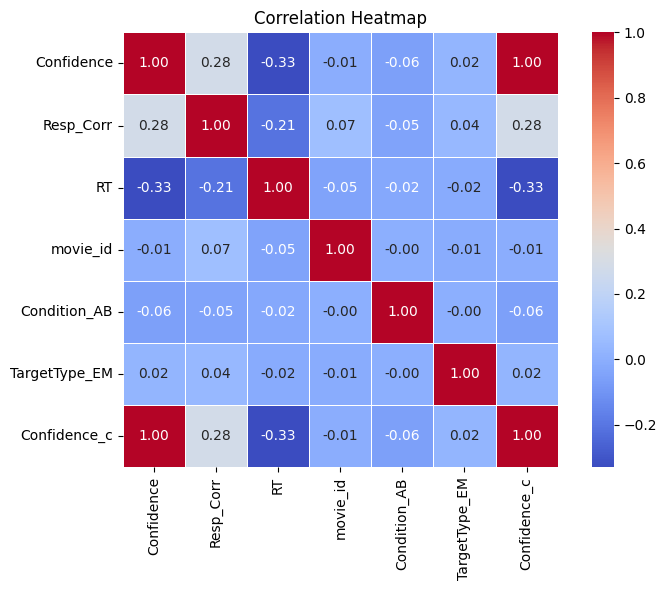

In [24]:
plot_correlation_heatmap(df)

In [25]:
import numpy as np
import pandas as pd

def logistic_regression_report(result):
    """
    Generate a full report for logistic regression:
    - Coefficients
    - Odds ratios
    - 95% CI
    - p-values
    - Text interpretation
    """

    print("\n" + "="*80)
    print("LOGISTIC REGRESSION REPORT")
    print("="*80)

    # Extract values
    params   = result.params
    conf_int = result.conf_int()
    pvals    = result.pvalues

    # Build table
    report_df = pd.DataFrame({
        'Coefficient (β)': params,
        'Odds Ratio (expβ)': np.exp(params),
        'CI Lower (2.5%)': np.exp(conf_int[0]),
        'CI Upper (97.5%)': np.exp(conf_int[1]),
        'p-value': pvals
    })

    # Significance stars
    def stars(p):
        if p < 0.001: return '***'
        elif p < 0.01: return '**'
        elif p < 0.05: return '*'
        else: return ''

    report_df['Significance'] = report_df['p-value'].apply(stars)

    print("\n📊 Model Summary Table:\n")
    print(report_df.to_string(float_format="{:.4f}".format))

    # ── Interpretation ───────────────────────────────────────────────
    print("\n" + "-"*80)
    print("INTERPRETATION")
    print("-"*80)

    for var in report_df.index:
        if var == 'Intercept':
            continue

        beta = report_df.loc[var, 'Coefficient (β)']
        or_val = report_df.loc[var, 'Odds Ratio (expβ)']
        p = report_df.loc[var, 'p-value']

        if p < 0.05:
            direction = "increases" if beta > 0 else "decreases"

            print(f"\n• {var} is a SIGNIFICANT predictor (p = {p:.4f}).")

            print(f"  → A one-unit increase in {var} {direction} the odds of correct response by "
                  f"{or_val:.2f} times.")

            if beta > 0:
                print(f"  → This means higher {var} is associated with HIGHER probability of correct recognition.")
            else:
                print(f"  → This means higher {var} is associated with LOWER probability of correct recognition.")
        else:
            print(f"\n• {var} is NOT a significant predictor (p = {p:.4f}).")

    # ── Most important predictors ────────────────────────────────────
    print("\n" + "-"*80)
    print("KEY TAKEAWAYS")
    print("-"*80)

    sig_vars = report_df[report_df['p-value'] < 0.05].copy()

    if not sig_vars.empty:
        sig_vars = sig_vars.sort_values(by='p-value')

        print("\nMost significant predictors (in order):")
        for var in sig_vars.index:
            if var == 'Intercept':
                continue
            print(f"  - {var} (p = {sig_vars.loc[var, 'p-value']:.4f})")
    else:
        print("No statistically significant predictors found.")

    print("\n" + "="*80)

    return report_df

In [26]:
# 3. Run logistic regression -----------------------------------------------
result = run_logistic_regression(df)



LOGISTIC REGRESSION (GLM - Binomial)
                 Generalized Linear Model Regression Results                  
Dep. Variable:              Resp_Corr   No. Observations:                 6640
Model:                            GLM   Df Residuals:                     6635
Model Family:                Binomial   Df Model:                            4
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2511.8
Date:                Wed, 22 Apr 2026   Deviance:                       5023.7
Time:                        16:37:19   Pearson chi2:                 6.54e+03
No. Iterations:                     5   Pseudo R-squ. (CS):            0.06941
Covariance Type:            nonrobust                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------

In [27]:
report = logistic_regression_report(result)


LOGISTIC REGRESSION REPORT

📊 Model Summary Table:

                           Coefficient (β)  Odds Ratio (expβ)  CI Lower (2.5%)  CI Upper (97.5%)  p-value Significance
Intercept                           1.9554             7.0667           6.2070            8.0453   0.0000          ***
Condition_AB                       -0.2379             0.7883           0.6753            0.9202   0.0026           **
TargetType_EM                       0.2100             1.2336           1.0691            1.4235   0.0040           **
Confidence_c                        0.6384             1.8934           1.7483            2.0505   0.0000          ***
Condition_AB:Confidence_c          -0.0931             0.9111           0.8170            1.0161   0.0943             

--------------------------------------------------------------------------------
INTERPRETATION
--------------------------------------------------------------------------------

• Condition_AB is a SIGNIFICANT predictor (p = 0.0026)